## Practica 2: python
## Análisis datos diabetes
## Estadisticas descriptivas
## 2026



In [26]:
## cargar los paquetes o toolbox

import numpy as np  ## manipulación de matrices
import pandas as pd ## carga el conjunto de datos
import matplotlib.pyplot as plt  ## sirve para graficar
import seaborn as sns  ## sirve para graficar
import scipy.stats as scp  ## contiene funciones de estadisticas

In [33]:
datos = pd.read_csv('Pima.tr.csv', sep='\s+')
datos

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2114/3333622357.py:1: SyntaxWarning: invalid escape sequence '\s'
  datos = pd.read_csv('Pima.tr.csv', sep='\s+')


,npreg,glu,bp,skin,bmi,ped,age,type
1,5,86,68,28,30.2,0.364,24,No
2,7,195,70,33,25.1,0.163,55,Yes
3,5,77,82,41,35.8,0.156,35,No
4,0,165,76,43,47.9,0.259,26,No
5,0,107,60,25,26.4,0.133,23,No
...,...,...,...,...,...,...,...,...
196,2,141,58,34,25.4,0.699,24,No
197,7,129,68,49,38.5,0.439,43,Yes
198,0,106,70,37,39.4,0.605,22,No
199,1,118,58,36,33.3,0.261,23,No


In [34]:
datos.describe()

,npreg,glu,bp,skin,bmi,ped,age
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,3.570000,123.970000,71.260000,29.215000,32.310000,0.460765,32.110000
std,3.366268,31.667225,11.479604,11.724594,6.130212,0.307225,10.975436
min,0.000000,56.000000,38.000000,7.000000,18.200000,0.085000,21.000000
25%,1.000000,100.000000,64.000000,20.750000,27.575000,0.253500,23.000000
50%,2.000000,120.500000,70.000000,29.000000,32.800000,0.372500,28.000000
75%,6.000000,144.000000,78.000000,36.000000,36.500000,0.616000,39.250000
max,14.000000,199.000000,110.000000,99.000000,47.900000,2.288000,63.000000


In [35]:
datos['type'].value_counts()

,count
type,
No,132
Yes,68


Text(0.5, 1.0, 'Diagrama de torta de la variable type')

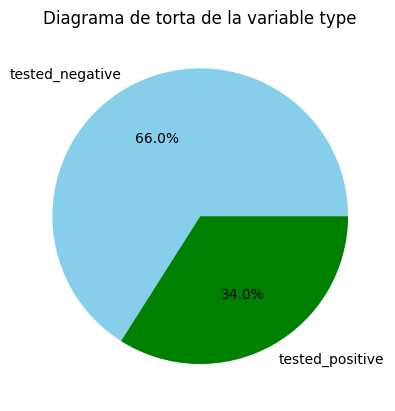

In [39]:
conteos=[132, 68]
labels=["tested_negative", "tested_positive"]
plt.pie(conteos, labels=labels, colors=["skyblue", "green"], autopct='%1.1f%%')
plt.title('Diagrama de torta de la variable type')

Text(0.5, 0, 'class')

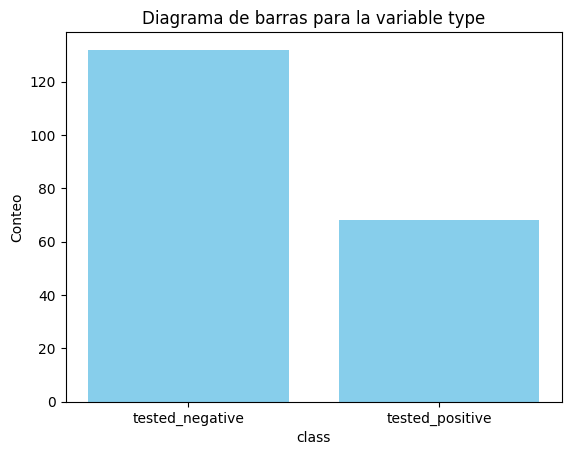

In [40]:
## Diagrama de Barras en Python
conteos=[132, 68]
labels=["tested_negative", "tested_positive"]
plt.bar(x=labels, height=conteos, color="skyblue")
plt.title('Diagrama de barras para la variable type')
plt.ylabel('Conteo')
plt.xlabel('class')

In [41]:
## promedio de la variable edad
np.mean(datos['age'])

np.float64(32.11)

In [42]:
## mediana de la variable edad
np.median(datos['age'])

np.float64(28.0)

In [43]:
np.max(datos['age'])

63

In [44]:
np.min(datos['age'])

21

In [45]:
## desviación estándar
np.std(datos.age)

10.947963280902984

In [46]:
## percentiles: indicadores de posición
np.percentile(datos['age'], q=25)
## El percentil 25% nos indica: El 25% de las mujeres tienen
## una edad menor o igual a 23 años.

np.float64(23.0)

Text(0.5, 1.0, 'Histograma de la variable Edad')

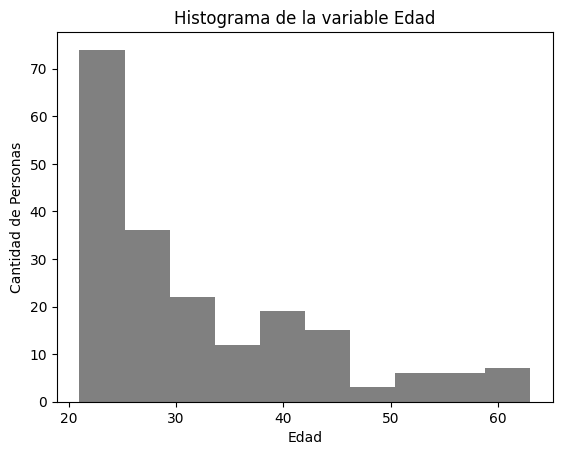

In [47]:
## Histograma
plt.hist(datos['age'], color='gray')
plt.ylabel('Cantidad de Personas')
plt.xlabel('Edad')
plt.title('Histograma de la variable Edad')

Text(0.5, 1.0, 'Diagrama de Cajas de la Variable Edad')

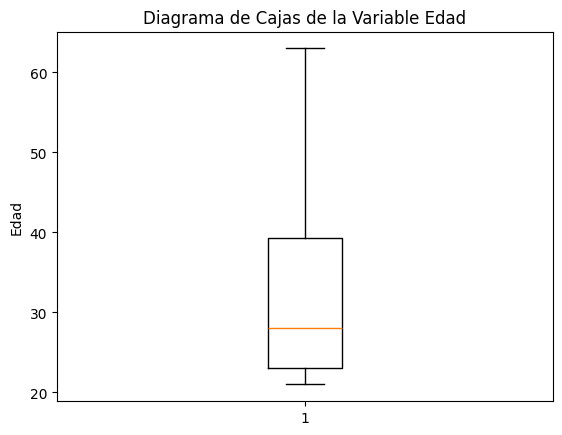

In [48]:
## Diagrama de cajas
plt.boxplot(datos['age'])
plt.ylabel('Edad')
plt.title('Diagrama de Cajas de la Variable Edad')

Text(0.5, 0, 'type')

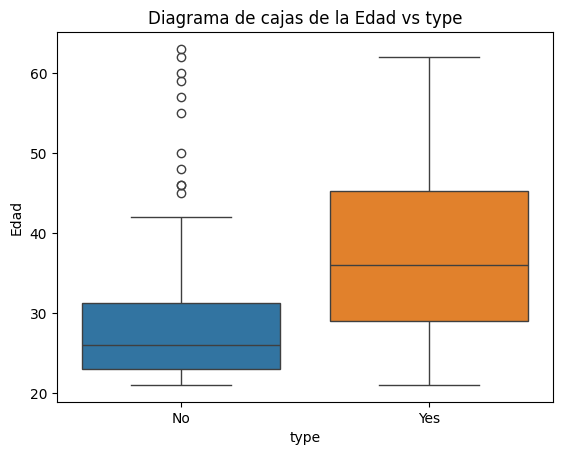

In [51]:
### Diagrama de cajas de la Edad vs Class
### https://python-charts.com/es/distribucion/box-plot-seaborn/
sns.boxplot(x='type', y='age', data=datos, hue="type")
plt.title('Diagrama de cajas de la Edad vs type')
plt.ylabel('Edad')
plt.xlabel('type')
## type si tiene diabetes o no..

Text(0.5, 0, 'type')

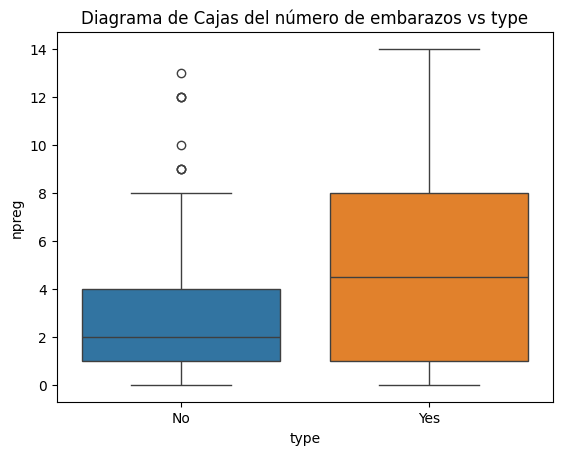

In [54]:
sns.boxplot(x='type', y='npreg', data=datos, hue='type')
plt.title('Diagrama de Cajas del número de embarazos vs type')
plt.ylabel('npreg')
plt.xlabel('type')

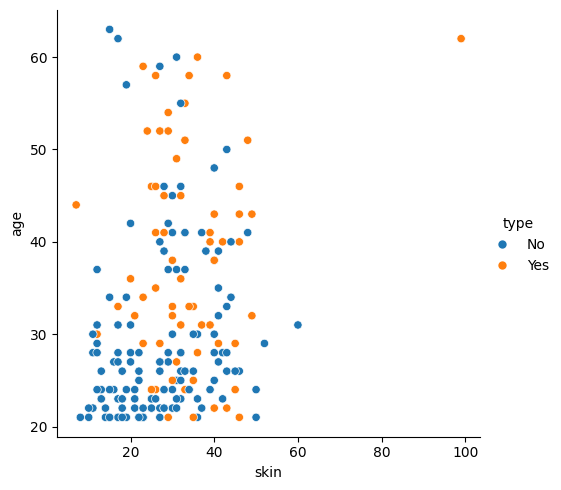

In [55]:
## Diagrama de Dispersión Edad vs Skin vs Diabetes (si o no)
sns.relplot(
    data=datos,
    x="skin", y="age",
    hue="type"
)

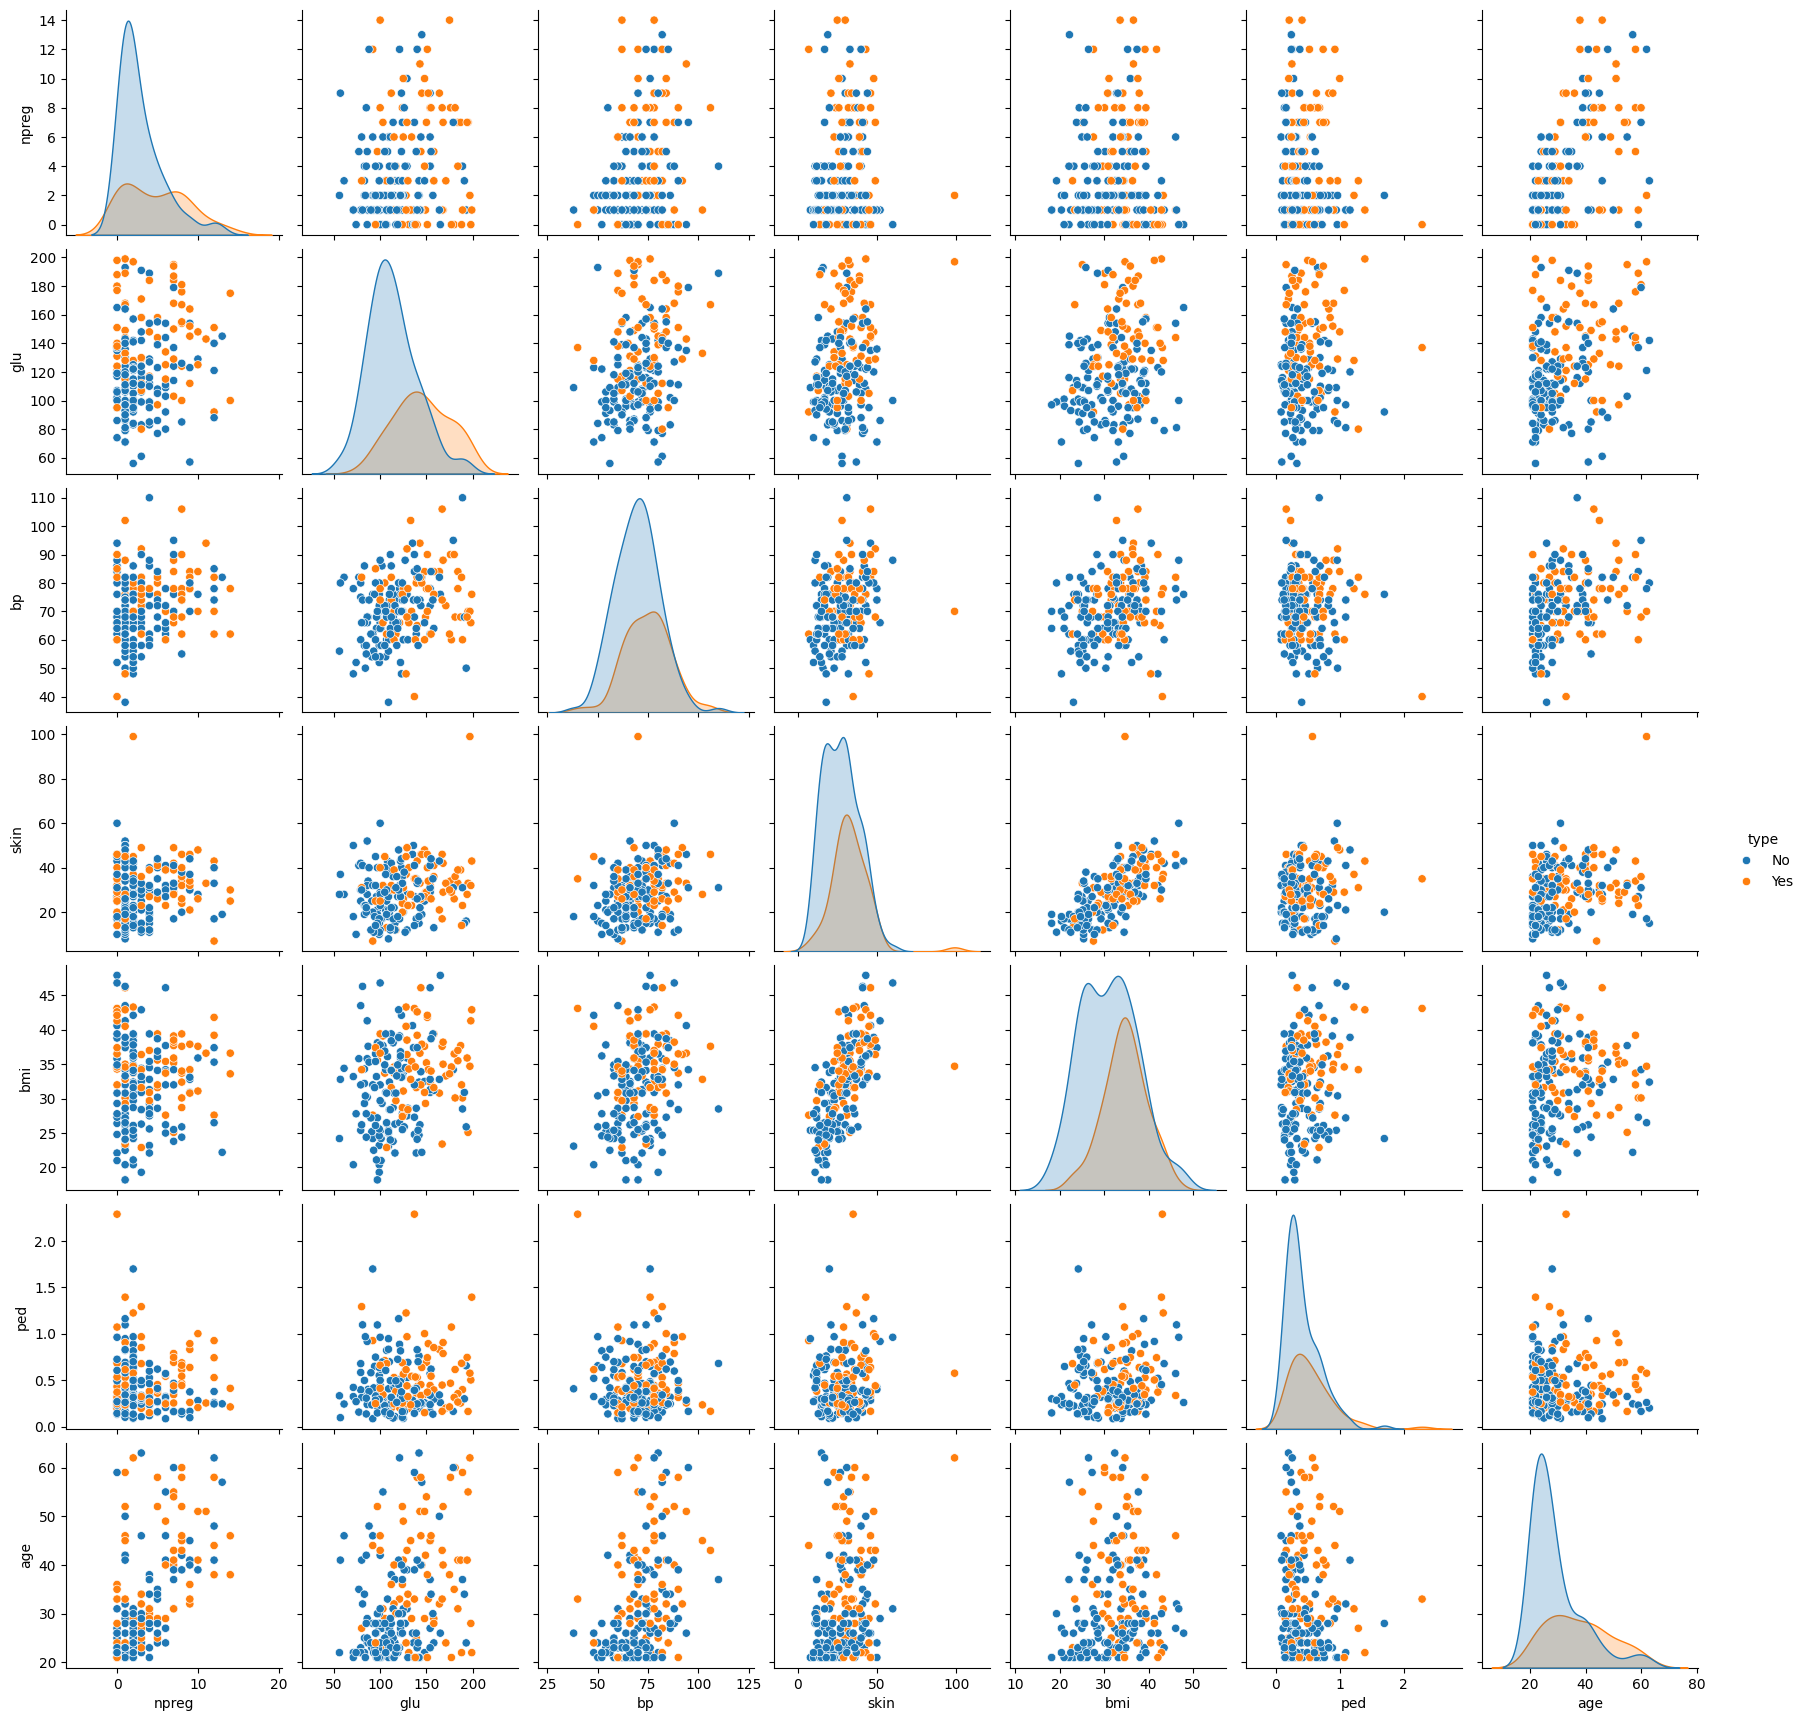

In [56]:
sns.pairplot(data=datos, hue="type")

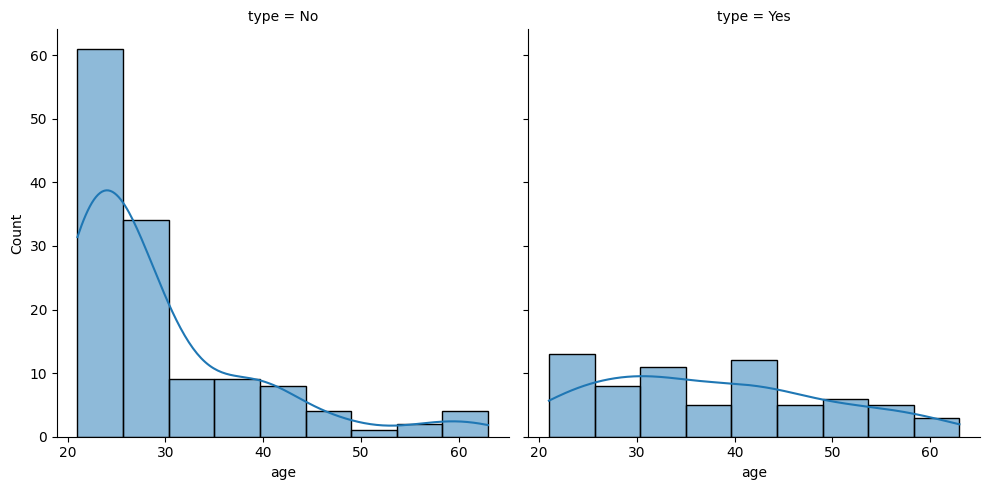

In [57]:
## histograma para cada grupo (Diabetes si y no)

sns.displot(data=datos, x="age", col="type", kde=True)
## https://seaborn.pydata.org/tutorial/introduction

In [58]:
### como calcular la asimetria

scp.skew(datos['age'])
## si es mayor que 0 indica datos asimetricos, sesgo positivo

np.float64(1.0879787255878512)

In [59]:
scp.kurtosis(datos['age'])
## indica que es un gráfico con caracteristicas platicurticas

np.float64(0.26698440212023655)

In [60]:
## correlacion de pearson
scp.pearsonr(datos['age'], datos['skin'])


PearsonRResult(statistic=np.float64(0.25192573583899885), pvalue=np.float64(0.00031986868889802213))